# 08 — Graph Sanity Check (Method G)

**Purpose.** This is a *visualisation* notebook, not a results notebook —
no F1, no gold links, no predictions. It sanity-checks that
`schema_linking.utils.graph.build_schema_graph` produces sensible
foreign-key graphs across all 166 Spider databases, and produces the
figures the methodology chapter uses to explain what Method G's graph
algorithm actually does: build a graph from FK relations, then complete a
set of LLM-named "core" tables into a connected table set via shortest
path (2 endpoints) or a greedy Steiner approximation (3 endpoints).

Sections:
1. Graph size distribution (nodes, edges, density) across all 166 DBs.
2. Graph connectivity — single vs multiple connected components.
3. Shortest-path / bridge-count distribution over all table pairs.
4. Three example schemas visualised as network diagrams.
5. A hand-picked Steiner example, with endpoints/path/other colour-coded.


In [1]:
import sys
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))

FIGURES_DIR = REPO_ROOT / 'notebooks' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from schema_linking.schema_parser import load_schemas
from schema_linking.utils.graph import build_schema_graph, steiner_subgraph_tables

pd.set_option('display.width', 140)

schemas = load_schemas()
graphs = {db_id: build_schema_graph(schema) for db_id, schema in schemas.items()}
print(f'{len(schemas)} schemas loaded, {len(graphs)} FK graphs built')

166 schemas loaded, 166 FK graphs built


## 1. Graph size distribution across 166 Spider DBs

Nodes = tables, edges = unique unordered table pairs sharing at least one
FK, density = `nx.density` (fraction of all possible node pairs that are
actually connected by an edge — `1.0` means every table pair shares an FK).

In [2]:
size_rows = []
for db_id, g in graphs.items():
    n_nodes = g.number_of_nodes()
    size_rows.append({
        'db_id': db_id,
        'n_nodes': n_nodes,
        'n_edges': g.number_of_edges(),
        'density': nx.density(g) if n_nodes > 1 else 0.0,
    })
size_df = pd.DataFrame(size_rows)
size_df[['n_nodes', 'n_edges', 'density']].describe().round(3)

,n_nodes,n_edges,density
count,166.000,166.000,166.000
mean,5.277,4.488,0.530
std,3.872,4.492,0.264
min,2.000,0.000,0.000
25%,3.000,2.000,0.333
50%,4.000,2.500,0.500
75%,7.000,6.000,0.667
max,26.000,24.000,1.000


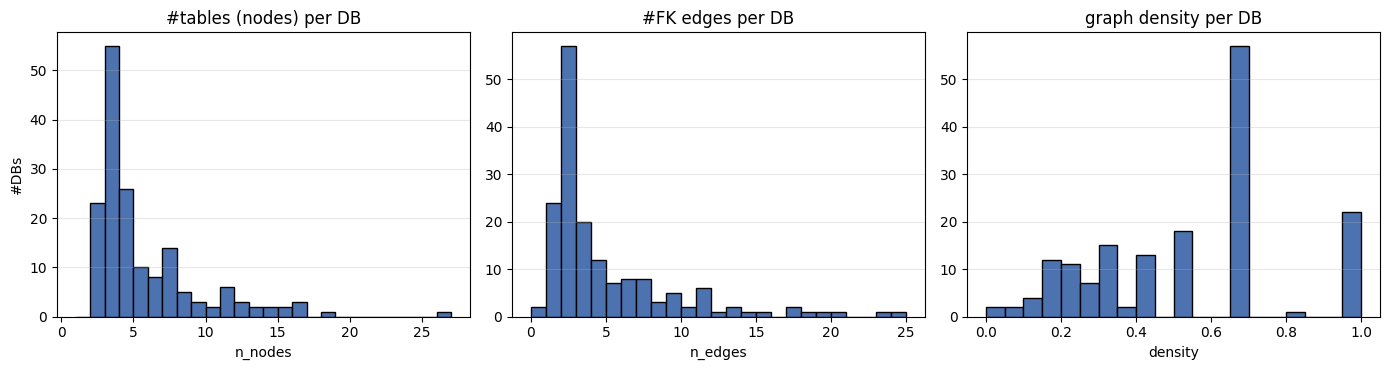

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].hist(size_df['n_nodes'], bins=range(1, size_df['n_nodes'].max() + 2), color='#4C72B0', edgecolor='black')
axes[0].set_title('#tables (nodes) per DB')
axes[0].set_xlabel('n_nodes')
axes[0].set_ylabel('#DBs')

axes[1].hist(size_df['n_edges'], bins=range(0, size_df['n_edges'].max() + 2), color='#4C72B0', edgecolor='black')
axes[1].set_title('#FK edges per DB')
axes[1].set_xlabel('n_edges')

axes[2].hist(size_df['density'], bins=20, color='#4C72B0', edgecolor='black')
axes[2].set_title('graph density per DB')
axes[2].set_xlabel('density')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Reading this.** Schema graphs are small and sparse, as expected for
relational schemas: median 4 tables / 2.5 FK edges per DB (mean pulled up
to 5.3 / 4.5 by a long tail — the largest DB has 26 tables). Median density
0.5 sounds high only because most graphs are tiny (a 3-4 node tree is
already "dense" by this metric); the largest, most FK-rich schemas are
correspondingly sparser.

## 2. Graph connectivity

Fraction of DBs whose FK graph is a single connected component vs.
multiple — and, when there is more than one component, how much of the
schema the largest one covers.

In [4]:
connectivity_rows = []
for db_id, g in graphs.items():
    n_components = nx.number_connected_components(g)
    largest_cc = max((len(c) for c in nx.connected_components(g)), default=0)
    n_nodes = g.number_of_nodes()
    connectivity_rows.append({
        'db_id': db_id,
        'n_nodes': n_nodes,
        'n_components': n_components,
        'largest_cc_size': largest_cc,
        'largest_cc_fraction': largest_cc / n_nodes if n_nodes else 0.0,
    })
connectivity_df = pd.DataFrame(connectivity_rows)

n_single = (connectivity_df['n_components'] == 1).sum()
n_multi = (connectivity_df['n_components'] > 1).sum()
display(Markdown(
    f'**Single connected component:** {n_single}/{len(connectivity_df)} DBs ({n_single / len(connectivity_df):.1%})  \n'
    f'**Multiple components:** {n_multi}/{len(connectivity_df)} DBs ({n_multi / len(connectivity_df):.1%})'
))

**Single connected component:** 136/166 DBs (81.9%)  
**Multiple components:** 30/166 DBs (18.1%)

In [5]:
multi_component_dbs = connectivity_df[connectivity_df['n_components'] > 1].sort_values('largest_cc_fraction')
multi_component_dbs[['db_id', 'n_nodes', 'n_components', 'largest_cc_size', 'largest_cc_fraction']].round(3)

,db_id,n_nodes,n_components,largest_cc_size,largest_cc_fraction
161,company_1,6,6,1,0.167
111,soccer_1,7,4,2,0.286
85,coffee_shop,4,2,2,0.500
126,student_1,2,2,1,0.500
134,bike_1,4,3,2,0.500
94,musical,2,2,1,0.500
110,hr_1,7,2,4,0.571
9,department_store,14,2,9,0.643
25,flight_2,3,2,2,0.667
64,e_government,10,2,7,0.700


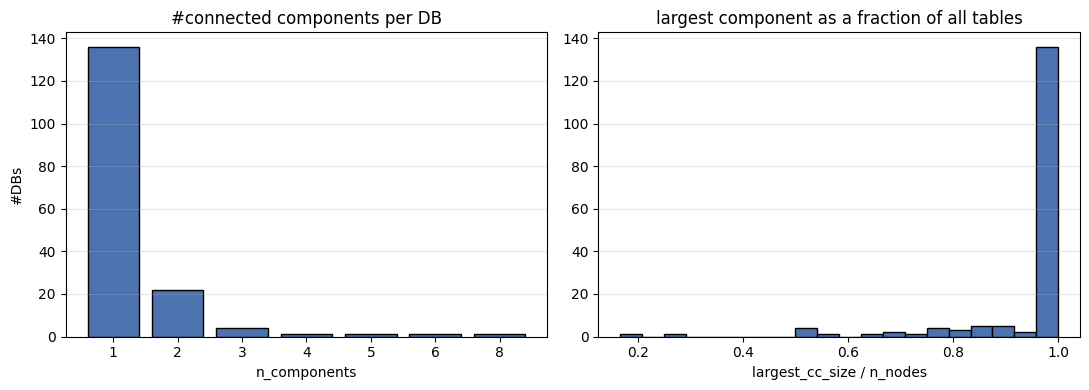

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

comp_counts = connectivity_df['n_components'].value_counts().sort_index()
axes[0].bar(comp_counts.index.astype(str), comp_counts.values, color='#4C72B0', edgecolor='black')
axes[0].set_title('#connected components per DB')
axes[0].set_xlabel('n_components')
axes[0].set_ylabel('#DBs')

axes[1].hist(connectivity_df['largest_cc_fraction'], bins=20, color='#4C72B0', edgecolor='black')
axes[1].set_title('largest component as a fraction of all tables')
axes[1].set_xlabel('largest_cc_size / n_nodes')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Reading this.** 136/166 (81.9%) of Spider DBs have a single connected FK
graph — every table reachable from every other. The 30 multi-component DBs
are not fragmented schemas so much as schemas with one or two genuinely
**isolated tables**: e.g. `world_1`'s `sqlite_sequence` (a SQLite-internal
bookkeeping table, not a real domain table at all) and `dog_kennels`'
`Charges` (no declared FK to anything else) each sit alone as their own
component while the rest of the schema stays fully connected — this is
exactly why `resolve_endpoint_table`/`build_schema_graph` deliberately
leave isolated tables as valid, edgeless nodes rather than erroring: they
are real, legitimate schema elements the LLM might still name as a
single-table endpoint, just ones the graph algorithm can never *bridge*
to anything else.

## 3. Shortest-path length / bridge-count distribution

Over every unordered pair of distinct tables within each DB: how many
*intermediate* tables does the shortest connecting path pass through?
`bridge_count = shortest_path_length_in_edges − 1` (a direct FK edge is
`bridge_count=0`). Pairs with no path at all (different connected
components) are counted separately — this is the corpus-wide analogue of
Method G's "endpoints correct but disconnected" fallback case.

In [7]:
bridge_counter: dict[int, int] = {}
n_disconnected_pairs = 0
n_total_pairs = 0

for g in graphs.values():
    for a, b in combinations(g.nodes, 2):
        n_total_pairs += 1
        try:
            path_len = nx.shortest_path_length(g, a, b)
            bridge_counter[path_len - 1] = bridge_counter.get(path_len - 1, 0) + 1
        except nx.NetworkXNoPath:
            n_disconnected_pairs += 1

max_bridge = max(bridge_counter)
bridge_series = pd.Series({k: bridge_counter.get(k, 0) for k in range(max_bridge + 1)})
bridge_series.index.name = 'bridge_count'
bridge_series.name = 'n_pairs'
display(Markdown(
    f'**Total table pairs across all 166 DBs:** {n_total_pairs}  \n'
    f'**Disconnected pairs (no path in their DB):** {n_disconnected_pairs} ({n_disconnected_pairs / n_total_pairs:.1%})'
))
bridge_series.to_frame()

**Total table pairs across all 166 DBs:** 3110  
**Disconnected pairs (no path in their DB):** 534 (17.2%)

,n_pairs
bridge_count,
0,742
1,921
2,550
3,262
4,81
5,17
6,3


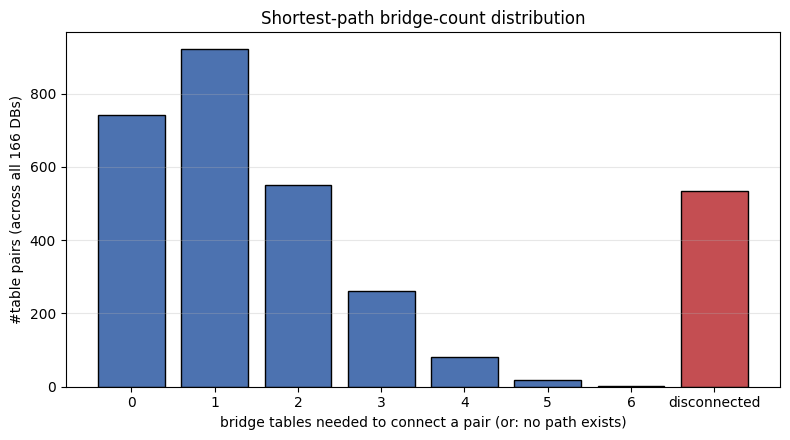

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [str(b) for b in bridge_series.index] + ['disconnected']
values = list(bridge_series.values) + [n_disconnected_pairs]
colors = ['#4C72B0'] * len(bridge_series) + ['#C44E52']
ax.bar(labels, values, color=colors, edgecolor='black')
ax.set_xlabel('bridge tables needed to connect a pair (or: no path exists)')
ax.set_ylabel('#table pairs (across all 166 DBs)')
ax.set_title('Shortest-path bridge-count distribution')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Reading this.** Among *connected* pairs, needing exactly **1** bridge
table is the single most common case (921 pairs) — marginally ahead of a
direct FK edge (742 pairs, 0 bridges); 2+ bridges tapers off quickly (550,
262, 81, 17, 3). This is direct evidence for what Method G's design bets
on: most real table-to-table connections in Spider schemas are either
immediate or one hop away, exactly the regime where a shortest-path/Steiner
completion is cheap and reliable. The **534 disconnected pairs (17.2% of
all pairs)** are the corpus-wide version of §2's isolated-table finding —
these are cases `shortest_path_tables`/`steiner_subgraph_tables` cannot
bridge at all and fall back to "include the terminal alone" (with a logged
warning), by design (see `tests/test_graph.py`).

## 4. Three example schemas as network diagrams

Hand-picked for topological variety: `concert_singer` (a linear chain),
`world_1` (a chain plus an isolated `sqlite_sequence` node), `wta_1` (a
star — `players` is the hub for both `matches` and `rankings`).

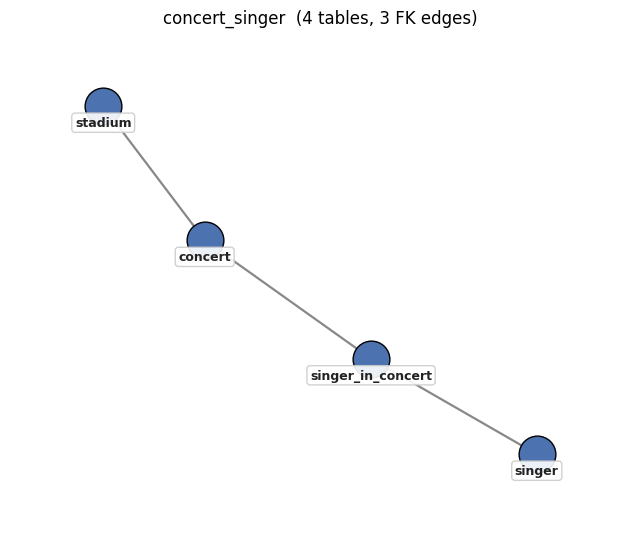

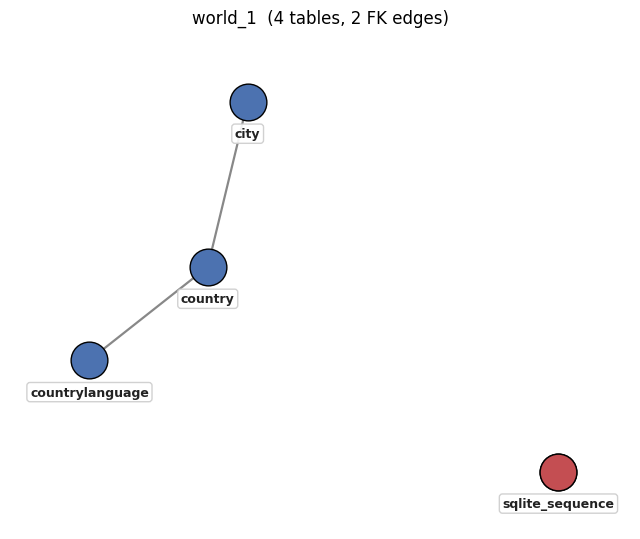

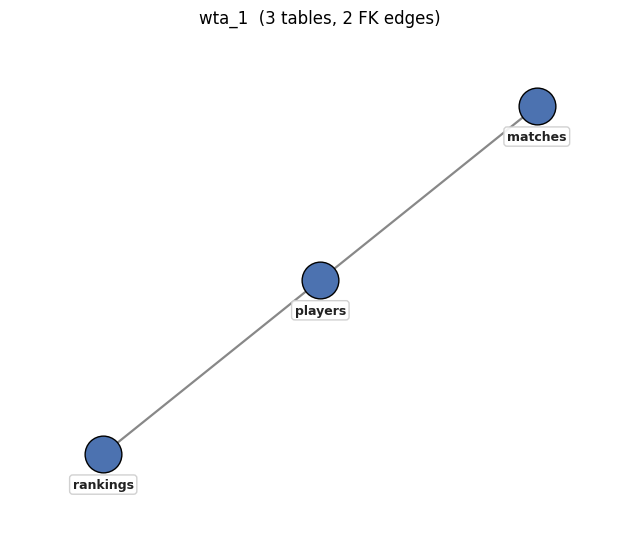

In [9]:
def draw_node_labels(g, pos, ax, label_dy=-0.09):
    # External labels (white background box, below each node) rather than
    # text packed inside the marker — robust to arbitrarily long table names
    # (e.g. "singer_in_concert", "Treatment_Types") that would otherwise clip.
    label_pos = {n: (x, y + label_dy) for n, (x, y) in pos.items()}
    nx.draw_networkx_labels(
        g, label_pos, ax=ax, font_size=9, font_weight='bold', font_color='#222222',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#CCCCCC', alpha=0.9),
    )


def draw_schema_graph(db_id: str, ax=None, seed: int = 42):
    g = graphs[db_id]
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
    pos = nx.spring_layout(g, seed=seed, k=1.1)

    nx.draw_networkx_edges(g, pos, ax=ax, edge_color='#888888', width=1.6)
    nx.draw_networkx_nodes(g, pos, ax=ax, node_color='#4C72B0', edgecolors='black', node_size=700)

    isolated = [n for n in g.nodes if g.degree(n) == 0]
    if isolated:
        nx.draw_networkx_nodes(
            g, pos, ax=ax, nodelist=isolated, node_color='#C44E52',
            edgecolors='black', node_size=700,
        )

    draw_node_labels(g, pos, ax)

    ax.set_title(f'{db_id}  ({g.number_of_nodes()} tables, {g.number_of_edges()} FK edges)')
    ax.axis('off')
    ax.margins(0.15)
    if own_fig:
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'fig_schema_graph_{db_id}.png', dpi=150, bbox_inches='tight')
        plt.show()


for db_id in ['concert_singer', 'world_1', 'wta_1']:
    draw_schema_graph(db_id)

**Reading this.** `concert_singer` is a textbook linear join chain
(`stadium — concert — singer_in_concert — singer`) — any 2-endpoint query
spanning both ends needs the full path. `world_1` shows §2's isolated-node
case directly: `sqlite_sequence` (red) has zero FK edges and sits outside
the `city — country — countrylanguage` chain entirely. `wta_1` is a star:
`players` is the shared hub for both `matches` and `rankings`, which are
never directly linked to each other — a 2-endpoint query naming
`matches`/`rankings` is bridged through `players` for free.

## 5. Steiner example — `dog_kennels`

A hand-picked bridge case with a genuine, non-trivial Steiner tree.
Terminals: `{Owners, Professionals, Dogs}` — none of the three share a
direct FK edge; all three connect only through `Treatments`. This is the
*exact* schema and endpoint pattern behind two real dev queries
(`SELECT state FROM Owners INTERSECT SELECT state FROM Professionals`-style
questions) examined in `notebooks/03_method_results.ipynb` §G.5 as a
graph-pathology case — shown here as a clean, isolated illustration of what
the algorithm itself does, independent of whether that SQL structure
actually calls for it.

In [10]:
dog_kennels_g = graphs['dog_kennels']
terminals = ['Owners', 'Professionals', 'Dogs']
steiner_result = set(steiner_subgraph_tables(dog_kennels_g, terminals))
bridge_nodes = steiner_result - set(terminals)

print(f'terminals:      {terminals}')
print(f'steiner result: {sorted(steiner_result)}')
print(f'bridge node(s): {sorted(bridge_nodes)}')

terminals:      ['Owners', 'Professionals', 'Dogs']
steiner result: ['Dogs', 'Owners', 'Professionals', 'Treatments']
bridge node(s): ['Treatments']


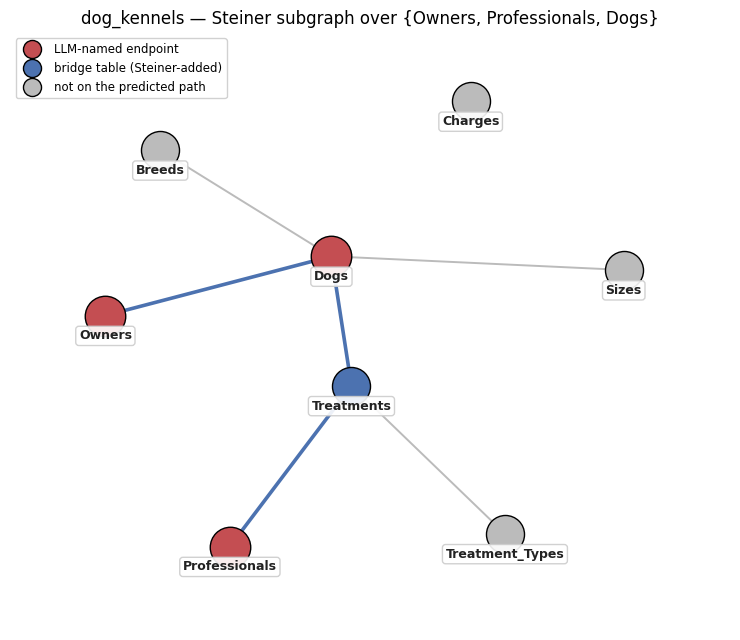

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
pos = nx.spring_layout(dog_kennels_g, seed=7, k=1.3)

# Induced subgraph on the Steiner result = the actual path/bridge edges.
path_edges = [
    (u, v) for u, v in dog_kennels_g.edges
    if u in steiner_result and v in steiner_result
]
other_edges = [e for e in dog_kennels_g.edges if e not in path_edges and (e[1], e[0]) not in path_edges]
other_nodes = [n for n in dog_kennels_g.nodes if n not in steiner_result]

nx.draw_networkx_edges(dog_kennels_g, pos, ax=ax, edgelist=other_edges, edge_color='#BBBBBB', width=1.4)
nx.draw_networkx_edges(dog_kennels_g, pos, ax=ax, edgelist=path_edges, edge_color='#4C72B0', width=2.6)

nx.draw_networkx_nodes(dog_kennels_g, pos, ax=ax, nodelist=other_nodes, node_color='#BBBBBB', edgecolors='black', node_size=750)
nx.draw_networkx_nodes(dog_kennels_g, pos, ax=ax, nodelist=list(bridge_nodes), node_color='#4C72B0', edgecolors='black', node_size=750)
nx.draw_networkx_nodes(dog_kennels_g, pos, ax=ax, nodelist=terminals, node_color='#C44E52', edgecolors='black', node_size=850)

draw_node_labels(dog_kennels_g, pos, ax)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#C44E52', markeredgecolor='black', markersize=13, label='LLM-named endpoint'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markeredgecolor='black', markersize=13, label='bridge table (Steiner-added)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#BBBBBB', markeredgecolor='black', markersize=13, label='not on the predicted path'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8.5, framealpha=0.9)
ax.set_title('dog_kennels — Steiner subgraph over {Owners, Professionals, Dogs}')
ax.axis('off')
ax.margins(0.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_schema_graph_steiner_example.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading this.** `Treatments` is never named by the LLM — it's pulled in
purely because it lies on the minimal tree connecting the three red
endpoints. `Breeds`, `Sizes`, `Charges`, and `Treatment_Types` (grey) stay
untouched even though `Breeds`/`Sizes` are one hop from `Dogs`, because
they aren't needed to connect the terminals. This is Method G's whole
mechanism in one picture: the LLM call decides *which tables matter*, the
graph algorithm decides *how they connect* — and, as
`notebooks/03_method_results.ipynb` §G.5 shows on real dev queries, that
mechanism is exactly right when the underlying SQL is a genuine join chain,
and exactly wrong when it isn't (e.g. a `UNION`/`INTERSECT` over
independently-queried tables that were never meant to be joined at all).